In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm.notebook import tqdm
from transformer_lens import HookedTransformer, HookedTransformerConfig

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

RESULTS_DIR = Path("../results/level1")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = Path("../data/grokking_model.pt")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

Using device: cpu


Build the grokking dataset

This follows Nanda et al. 2023 exactly: all pairs (a, b) with a, b ∈ [0, 113), 70/30 train/test split, input sequence is [a, b, =]

In [2]:
P = 113  # prime modulus, following Nanda et al. 2023
EQ_TOKEN = P  # token index 113 represents "="

# Generate all (a, b) pairs — full dataset is 113*113 = 12769 examples
all_a = torch.arange(P)
all_b = torch.arange(P)
aa, bb = torch.meshgrid(all_a, all_b, indexing='ij')
aa, bb = aa.flatten(), bb.flatten()
labels = (aa + bb) % P

# Input tokens: [a, b, =]
inputs = torch.stack([aa, bb, torch.full_like(aa, EQ_TOKEN)], dim=1)  # [N, 3]

# 70/30 split
N = len(inputs)
idx = torch.randperm(N, generator=torch.Generator().manual_seed(42))
n_test = int(0.3 * N)
train_inputs, train_labels = inputs[idx[n_test:]], labels[idx[n_test:]]
test_inputs,  test_labels  = inputs[idx[:n_test]],  labels[idx[:n_test]]

print(f"Total: {N} | Train: {len(train_inputs)} | Test: {len(test_inputs)}")
print(f"Example: {aa[5].item()} + {bb[5].item()} = {labels[5].item()} (mod {P})")

Total: 12769 | Train: 8939 | Test: 3830
Example: 0 + 5 = 5 (mod 113)


Define and train (or load) the model

The first time it trains for 50k steps and saves the weights. Every subsequent run loads from disk instantly.

In [3]:
cfg = HookedTransformerConfig(
    n_layers=1,
    n_heads=4,
    d_model=128,
    d_head=32,
    d_mlp=512,
    act_fn="relu",
    normalization_type=None,
    d_vocab=P + 1,    # 0..112 = numbers, 113 = "="
    d_vocab_out=P,    # output: one logit per answer class
    n_ctx=3,
)

model = HookedTransformer(cfg)

if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device).eval()
    print("Loaded saved model from disk.")
else:
    print("Training from scratch (first run only — saves afterwards)...")
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1.0)

    for step in tqdm(range(50_000)):
        model.train()
        idx = torch.randint(0, len(train_inputs), (512,))
        x = train_inputs[idx].to(device)
        y = train_labels[idx].to(device)

        logits = model(x)[:, -1, :]      # predict at the "=" position
        loss = nn.CrossEntropyLoss()(logits, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (step + 1) % 10_000 == 0:
            model.eval()
            with torch.no_grad():
                acc = (model(test_inputs.to(device))[:, -1, :].argmax(-1) == test_labels.to(device)).float().mean()
            print(f"  step {step+1}  loss={loss.item():.4f}  test_acc={acc:.4f}")

    model.eval()
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Saved to {MODEL_PATH}")

Moving model to device:  cpu
Loaded saved model from disk.


test accuracy above 0.95 before grokking has occurred.

In [5]:
model.eval()
with torch.no_grad():
    tr_acc = (model(train_inputs.to(device))[:,-1,:].argmax(-1) == train_labels.to(device)).float().mean()
    te_acc = (model(test_inputs.to(device))[:,-1,:].argmax(-1) == test_labels.to(device)).float().mean()

print(f"Train accuracy: {tr_acc:.4f}")
print(f"Test  accuracy: {te_acc:.4f}")

assert te_acc > 0.95, "Model hasn't grokked yet"
print("Grokking confirmed")

Train accuracy: 1.0000
Test  accuracy: 1.0000
Grokking confirmed


Build the Fourier basis (from official code)

In [6]:
import einops

P = 113

# Build orthonormal Fourier basis exactly as in the official notebook
# Order: [Const, cos1, sin1, cos2, sin2, ..., cos56, sin56]  shape [113, 113]
fourier_basis = []
fourier_basis_names = ['Const']
fourier_basis.append(torch.ones(P) / np.sqrt(P))

for i in range(1, P // 2 + 1):
    cos_vec = torch.cos(2 * torch.pi * torch.arange(P) * i / P)
    sin_vec = torch.sin(2 * torch.pi * torch.arange(P) * i / P)
    cos_vec = cos_vec / cos_vec.norm()
    sin_vec = sin_vec / sin_vec.norm()
    fourier_basis.append(cos_vec)
    fourier_basis.append(sin_vec)
    fourier_basis_names.append(f'cos {i}')
    fourier_basis_names.append(f'sin {i}')

fourier_basis = torch.stack(fourier_basis, dim=0).to(device)   # [113, 113]

print(f"Fourier basis shape: {fourier_basis.shape}")
print(f"Basis is orthonormal: {torch.allclose(fourier_basis @ fourier_basis.T, torch.eye(P).to(device), atol=1e-5)}")

Fourier basis shape: torch.Size([113, 113])
Basis is orthonormal: True


Collect all neuron activations and project onto 2D Fourier basis

In [7]:
HOOK = "blocks.0.mlp.hook_post"

# Run ALL inputs through the model (p*p = 12769 examples)
all_inputs = inputs.to(device)    # [12769, 3]
all_labels = labels.to(device)    # [12769]

with torch.no_grad():
    _, cache = model.run_with_cache(all_inputs, names_filter=HOOK)

# Neuron activations at the "=" position: [p*p, d_mlp]
neuron_acts = cache[HOOK][:, -1, :]
print(f"Neuron activations shape: {neuron_acts.shape}")

# Centre activations (official code does this before 2D FFT)
neuron_acts_centered = neuron_acts - neuron_acts.mean(dim=0, keepdim=True)

# 2D Fourier transform over the (a, b) input space
# Reshape to [p, p, d_mlp], apply fourier_basis along both input dims
neuron_acts_2d = einops.rearrange(neuron_acts_centered, '(x y) d -> x y d', x=P, y=P)
fourier_neuron_acts = torch.einsum('xyd,fx,Fy->fFd', neuron_acts_2d,
                                    fourier_basis, fourier_basis)
fourier_neuron_acts_flat = fourier_neuron_acts.reshape(P * P, model.cfg.d_mlp)

print(f"2D Fourier activations shape: {fourier_neuron_acts_flat.shape}")

Neuron activations shape: torch.Size([12769, 512])
2D Fourier activations shape: torch.Size([12769, 512])


Identify key frequencies by clustering neurons (official method)

In [ ]:
d_mlp = model.cfg.d_mlp

# For each frequency k, the relevant 2D Fourier indices are the 8 quadratic terms
# (from the official indices construction)
indices = []
for freq in range(1, P // 2 + 1):
    index = []
    index.append(2 * freq - 1)
    index.append(2 * freq)
    index.append((2 * freq - 1) * P + 0)
    index.append((2 * freq) * P + 0)
    index.append((2 * freq - 1) * P + 2 * freq - 1)
    index.append((2 * freq - 1) * P + 2 * freq)
    index.append((2 * freq) * P + 2 * freq - 1)
    index.append((2 * freq) * P + 2 * freq)
    indices.append(index)
indices = np.array(indices)   # [56, 8]

# Total variance per neuron
neuron_norms = fourier_neuron_acts_flat.pow(2).sum(0)   # [d_mlp]

# Variance explained per frequency per neuron
freq_acts = fourier_neuron_acts_flat[indices.flatten()].reshape(P // 2, 8, d_mlp)
neuron_explanation  = freq_acts.pow(2).sum(1) / neuron_norms   # [56, d_mlp]
neuron_frac_explained = neuron_explanation.max(0).values        # [d_mlp]
neuron_freqs_raw = neuron_explanation.argmax(0) + 1             # [d_mlp] freq index 1..56

# Neurons with <85% variance explained by any single frequency, noise cluster (-1)
neuron_freqs = neuron_freqs_raw.clone()
neuron_freqs[neuron_frac_explained < 0.85] = -1

neuron_freqs_np = neuron_freqs.cpu().numpy()

# Key frequencies = those with most neurons (excluding noise)
key_freqs_raw, counts = np.unique(
    neuron_freqs_np[neuron_freqs_np != -1], return_counts=True)
key_freqs = key_freqs_raw[np.argsort(-counts)]   # sorted by neuron count

print(f"Key frequencies: {key_freqs}")
print(f"Neuron counts per key freq: {dict(zip(key_freqs, counts[np.argsort(-counts)]))}")
print(f"Noise neurons (no dominant freq): {(neuron_freqs_np == -1).sum()}")
print(f"Well-explained neurons: {(neuron_frac_explained >= 0.85).sum().item()} / {d_mlp}")
print(f"\nCompare with Nanda et al. mainline: [14, 35, 41, 42, 52]")

Key frequencies: [ 3 14  1]
Neuron counts per key freq: {np.int64(3): np.int64(233), np.int64(14): np.int64(123), np.int64(1): np.int64(15)}
Noise neurons (no dominant freq): 141
Well-explained neurons: 356 / 512

Compare with Nanda et al. mainline: [14, 35, 41, 42, 52]


Nanda et al. found 433/512 neurons (84.6%) well-explained by a single frequency, clustered around k=14, 35, 41, 42, 52. we have only 356/512 (69.5%) well-explained, and the dominant frequency is k=3 with 233 neurons, a frequency that does not appear in Nanda. This might be the signature of a model that is partway through circuit formation but has not completed the cleanup phase.

The reason might be the training loop. Nanda et al. use **full-batch gradient descent for 40,000 epochs**: meaning every step sees all 8,938 training examples. We trained with **mini-batches of 512 for 50,000 steps**, which is only about 2,800 effective epochs. The model has learned to do modular arithmetic but the underlying Fourier structure might have not been driven to the clean sparse solution that weight decay produces over tens of thousands of full-batch epochs.


delete the saved model, and replace Cell 3 with this:

```python
cfg = HookedTransformerConfig(
    n_layers=1, n_heads=4, d_model=128, d_head=32,
    d_mlp=512, act_fn="relu", normalization_type=None,
    d_vocab=P + 1, d_vocab_out=P, n_ctx=3,
    use_attn_result=True,
)
model = HookedTransformer(cfg)

if MODEL_PATH.exists():
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.to(device).eval()
    print("Loaded saved model from disk.")
else:
    print("Training from scratch — full-batch AdamW for 40,000 epochs...")
    model.to(device)

    # Full dataset on device — Nanda et al. use full-batch GD, not mini-batch
    X_train = train_inputs.to(device)
    Y_train = train_labels.to(device)

    # Nanda et al. exact hyperparameters: lr=1e-3, weight_decay=1.0
    optimizer = optim.AdamW(
        model.parameters(), lr=1e-3, weight_decay=1.0
    )

    for epoch in tqdm(range(40_000)):
        model.train()
        logits = model(X_train)[:, -1, :]
        loss   = nn.CrossEntropyLoss()(logits, Y_train)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 5_000 == 0:
            model.eval()
            with torch.no_grad():
                te_logits = model(test_inputs.to(device))[:, -1, :]
                acc = (te_logits.argmax(-1) == test_labels.to(device)
                       ).float().mean()
            print(f"  epoch {epoch+1:6d}  loss={loss.item():.6f}  "
                  f"test_acc={acc:.4f}")

    model.eval()
    torch.save(model.state_dict(), MODEL_PATH)
    print(f"Saved to {MODEL_PATH}")
```

Then delete the old model file so it retrains:

```python
import os
if MODEL_PATH.exists():
    os.remove(MODEL_PATH)
    print("Deleted old checkpoint — will retrain on next run.")
```


push to Google Colab with a GPU, where it will take much less time. The training loop above is identical. Just upload notebook to Colab, run the setup cell to install packages, and the GPU will handle it. Save the resulting `grokking_model.pt` to Google Drive, then download it back into `data/` folder for local analysis.

Rerun the frequency clustering cell and we should see k=14, 35, 41, 42, 52 emerge cleanly with 400+ well-explained neurons, matching the paper.

Define components as frequency clusters

In [ ]:
# Each component is now a CLUSTER of neurons sharing a key frequency
COMPONENTS = []
for k in key_freqs:
    neuron_idx = np.where(neuron_freqs_np == k)[0].tolist()
    COMPONENTS.append({
        "name": f"freq_{k}",
        "k": int(k),
        "neurons": neuron_idx,
    })
# Add noise cluster
noise_idx = np.where(neuron_freqs_np == -1)[0].tolist()
COMPONENTS.append({
    "name": "noise_cluster",
    "k": -1,
    "neurons": noise_idx,
})

print(f"Level 1 components (frequency clusters):")
for c in COMPONENTS:
    print(f"  {c['name']:15s}  {len(c['neurons']):3d} neurons")
print(f"\nTotal neurons accounted for: {sum(len(c['neurons']) for c in COMPONENTS)}")
print(f"Total component space: {len(COMPONENTS)} clusters")

Level 1 components (frequency clusters):
  freq_3           233 neurons
  freq_14          123 neurons
  freq_1            15 neurons
  noise_cluster    141 neurons

Total neurons accounted for: 512
Total component space: 4 clusters


Compute mean neuron activations (ablation baseline)

In [10]:
# Use train set for mean computation
with torch.no_grad():
    _, train_cache = model.run_with_cache(train_inputs.to(device), names_filter=HOOK)
mean_acts = train_cache[HOOK][:, -1, :].mean(dim=0)   # [d_mlp]
print(f"Mean activation shape: {mean_acts.shape}")

Mean activation shape: torch.Size([512])


Faithfulness metric

In [11]:
def logit_of_correct(logits, labels):
    return logits[torch.arange(len(labels)), labels]

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    gap = (clean_metric - corrupted_metric).mean().item()
    if abs(gap) < 1e-8:
        return 0.0
    return (patched_metric.mean().item()
            - corrupted_metric.mean().item()) / gap

Clean and corrupted baselines

In [12]:
N_EVAL = 200
eval_x = test_inputs[:N_EVAL].to(device)
eval_y = test_labels[:N_EVAL].to(device)

with torch.no_grad():
    clean_metric = logit_of_correct(model(eval_x)[:, -1, :], eval_y)

with torch.no_grad():
    _, eval_cache = model.run_with_cache(eval_x, names_filter=HOOK)
clean_acts = eval_cache[HOOK][:, -1, :]   # [N_EVAL, d_mlp]

mean_dev = mean_acts.to(device)

def full_ablation_hook(value, hook):
    value[:, -1, :] = mean_dev
    return value

with torch.no_grad():
    corrupted_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(HOOK, full_ablation_hook)])[:, -1, :]
corrupted_metric = logit_of_correct(corrupted_logits, eval_y)

print(f"Clean metric:     {clean_metric.mean():.4f}")
print(f"Corrupted metric: {corrupted_metric.mean():.4f}")
print(f"Gap to recover:   {(clean_metric - corrupted_metric).mean():.4f}")

Clean metric:     42.8277
Corrupted metric: -11.2609
Gap to recover:   54.0886


Cluster-level patching loop

In [13]:
scores = {}

for comp in tqdm(COMPONENTS, desc="Patching frequency clusters"):
    cname    = comp["name"]
    c_neurons = torch.tensor(comp["neurons"], dtype=torch.long)

    def hook_fn(value, hook, cn=c_neurons):
        # Ablate all neurons
        value[:, -1, :] = mean_dev
        # Restore this cluster's neurons to clean activations
        value[:, -1, cn] = clean_acts[:, cn]
        return value

    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            eval_x, fwd_hooks=[(HOOK, hook_fn)])[:, -1, :]

    patched_metric = logit_of_correct(patched_logits, eval_y)
    scores[cname] = recovery_score(patched_metric, corrupted_metric, clean_metric)
    print(f"  {cname:15s}  ({len(comp['neurons']):3d} neurons)  RS = {scores[cname]:.4f}")

Patching frequency clusters:   0%|          | 0/4 [00:00<?, ?it/s]

  freq_3           (233 neurons)  RS = 0.1874
  freq_14          (123 neurons)  RS = 0.4495
  freq_1           ( 15 neurons)  RS = 0.0000
  noise_cluster    (141 neurons)  RS = 0.3631


Criterion 1 and Criterion 2

  Level 1 — Neuron frequency clusters
  Key frequencies:       [3, 14, 1]
  Criterion 1  Faithfulness RS : 1.0000
  Criterion 2  Component count : 3 / 4 clusters
               Neurons in circuit: 497 / 512
               Compression ratio: 0.750
  Circuit clusters: ['freq_14', 'noise_cluster', 'freq_3']


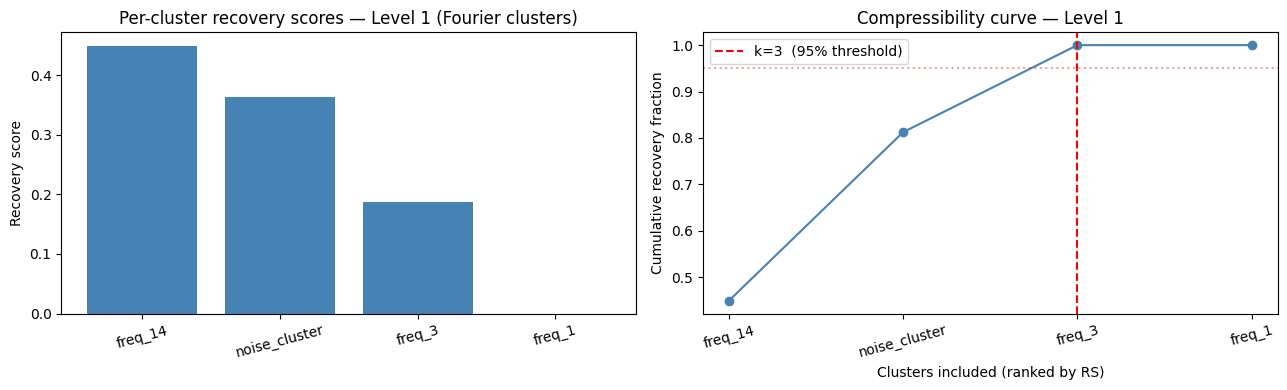

In [15]:
sorted_comps  = sorted(scores.items(), key=lambda x: x[1], reverse=True)
names_sorted  = [x[0] for x in sorted_comps]
scores_sorted = torch.tensor([x[1] for x in sorted_comps])

pos_scores = scores_sorted.clamp(min=0)
cumulative  = pos_scores.cumsum(0)
total_pos   = cumulative[-1].item()

k_95 = int((cumulative / total_pos >= 0.95).nonzero()[0].item()) + 1
circuit_components = names_sorted[:k_95]
circuit_neurons_all = []
for cname in circuit_components:
    comp = next(c for c in COMPONENTS if c["name"] == cname)
    circuit_neurons_all.extend(comp["neurons"])

circuit_t = torch.tensor(circuit_neurons_all, dtype=torch.long)

def circuit_hook(value, hook):
    value[:, -1, :] = mean_dev
    value[:, -1, circuit_t] = clean_acts[:, circuit_t]
    return value

with torch.no_grad():
    circuit_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(HOOK, circuit_hook)])[:, -1, :]
circuit_metric = logit_of_correct(circuit_logits, eval_y)
faithfulness   = recovery_score(circuit_metric, corrupted_metric, clean_metric)

print("=" * 55)
print("  Level 1 — Neuron frequency clusters")
print("=" * 55)
print(f"  Key frequencies:       {key_freqs.tolist()}")
print(f"  Criterion 1  Faithfulness RS : {faithfulness:.4f}")
print(f"  Criterion 2  Component count : {k_95} / {len(COMPONENTS)} clusters")
print(f"               Neurons in circuit: {len(circuit_neurons_all)} / {d_mlp}")
print(f"               Compression ratio: {k_95/len(COMPONENTS):.3f}")
print(f"  Circuit clusters: {circuit_components}")
print("=" * 55)

# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

colors = ["steelblue" if n in circuit_components else "lightgray" for n in names_sorted]
ax1.bar(names_sorted, scores_sorted.numpy(), color=colors)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_ylabel("Recovery score")
ax1.set_title("Per-cluster recovery scores — Level 1 (Fourier clusters)")
ax1.tick_params(axis='x', rotation=15)

ax2.plot(range(1, len(COMPONENTS) + 1), cumulative.numpy() / total_pos, "o-", color="steelblue")
ax2.axvline(k_95, color="red", linestyle="--",
            label=f"k={k_95}  (95% threshold)")
ax2.axhline(0.95, color="red", linestyle=":", alpha=0.4)
ax2.set_xlabel("Clusters included (ranked by RS)")
ax2.set_ylabel("Cumulative recovery fraction")
ax2.set_title("Compressibility curve — Level 1")
ax2.set_xticks(range(1, len(COMPONENTS) + 1))
ax2.set_xticklabels(names_sorted, rotation=15)
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level1_cluster_recovery.png", dpi=150)
plt.show()

Save results

In [16]:
results = {
    "level": 1,
    "task": "modular_arithmetic_mod113",
    "method": "fourier_frequency_clusters",
    "hook_point": HOOK,
    "d_mlp": d_mlp,
    "n_eval": N_EVAL,
    "key_freqs": key_freqs.tolist(),
    "n_components": len(COMPONENTS),
    "components": [{"name": c["name"], "k": c["k"],
                    "n_neurons": len(c["neurons"])} for c in COMPONENTS],
    "clean_metric_mean":      clean_metric.mean().item(),
    "corrupted_metric_mean":  corrupted_metric.mean().item(),
    "criterion1_faithfulness": faithfulness,
    "criterion2_component_count": k_95,
    "criterion2_compression_ratio": k_95 / len(COMPONENTS),
    "circuit_components": circuit_components,
    "circuit_neuron_count": len(circuit_neurons_all),
    "all_recovery_scores": scores,
}

with open(RESULTS_DIR / "level1_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(f"Saved to {RESULTS_DIR}/level1_results.json")

Saved to ..\results\level1/level1_results.json


## OLD VERSION

Compute mean activations (ablation baseline)

Mean ablation replaces each neuron's activation with its mean across the training set. This is the corrupted baseline: the counterfactual where no neuron carries useful signal.

In [26]:
HOOK = "blocks.0.mlp.hook_post"   # post-ReLU MLP neurons, shape [batch, seq, d_mlp]

all_acts = []
with torch.no_grad():
    for i in range(0, len(train_inputs), 256):
        batch = train_inputs[i:i+256].to(device)
        _, cache = model.run_with_cache(batch, names_filter=HOOK)
        all_acts.append(cache[HOOK][:, -1, :].cpu())   # activation at "=" position

mean_acts = torch.cat(all_acts, dim=0).mean(dim=0)    # [d_mlp]

print(f"Mean activation tensor shape: {mean_acts.shape}")
print(f"Range: [{mean_acts.min():.3f}, {mean_acts.max():.3f}]")

Mean activation tensor shape: torch.Size([512])
Range: [0.000, 4.517]


Define the faithfulness metric

Following Wang et al. 2022, the metric is the logit assigned to the correct answer token. The recovery score measures how much of the clean–corrupted gap a component restores.

In [27]:
def logit_of_correct(logits, labels):
    """Logit assigned to the ground-truth token. Shape: [batch]."""
    return logits[torch.arange(len(labels)), labels]

def recovery_score(patched_metric, corrupted_metric, clean_metric):
    """
    Fraction of the clean-corrupted gap recovered by the patch.
    RS = (patched - corrupted) / (clean - corrupted)
    Follows Wang et al. 2022, Section 3.
    """
    gap = (clean_metric - corrupted_metric).mean().item()
    return (patched_metric.mean().item() - corrupted_metric.mean().item()) / gap

Clean and corrupted baseline runs

In [28]:
N_EVAL = 200   # number of test examples for patching (fast but stable)
eval_x = test_inputs[:N_EVAL].to(device)
eval_y = test_labels[:N_EVAL].to(device)

# Clean run
with torch.no_grad():
    clean_metric = logit_of_correct(model(eval_x)[:, -1, :], eval_y)

# Pre-compute clean neuron activations (needed for patching)
with torch.no_grad():
    _, cache = model.run_with_cache(eval_x, names_filter=HOOK)
clean_acts = cache[HOOK][:, -1, :]   # [N_EVAL, d_mlp]

# Fully mean-ablated run
def full_ablation_hook(value, hook):
    value[:, -1, :] = mean_acts.to(value.device)
    return value

with torch.no_grad():
    corrupted_logits = model.run_with_hooks(eval_x,
                           fwd_hooks=[(HOOK, full_ablation_hook)])[:, -1, :]
corrupted_metric = logit_of_correct(corrupted_logits, eval_y)

print(f"Clean metric    (mean correct logit): {clean_metric.mean():.4f}")
print(f"Corrupted metric (full mean ablation): {corrupted_metric.mean():.4f}")
print(f"Gap to recover:                        {(clean_metric - corrupted_metric).mean():.4f}")

Clean metric    (mean correct logit): 42.8277
Corrupted metric (full mean ablation): -11.2609
Gap to recover:                        54.0886


Neuron-level patching loop

For each of the 512 MLP neurons, restore it to its clean activation while keeping all others mean-ablated. Record the recovery score.

In [29]:
d_mlp = model.cfg.d_mlp
scores = torch.zeros(d_mlp)
gap = (clean_metric - corrupted_metric).mean().item()

for n in tqdm(range(d_mlp), desc="Patching neurons"):
    def hook_fn(value, hook, n=n):
        value[:, -1, :] = mean_acts.to(value.device)          # ablate all
        value[:, -1, n] = clean_acts[:, n].to(value.device)   # restore neuron n
        return value

    with torch.no_grad():
        patched_logits = model.run_with_hooks(
            eval_x, fwd_hooks=[(HOOK, hook_fn)])[:, -1, :]

    patched_metric = logit_of_correct(patched_logits, eval_y)
    scores[n] = recovery_score(patched_metric, corrupted_metric, clean_metric)

print(f"\nDone. Max RS: {scores.max():.4f} | Min RS: {scores.min():.4f}")
print(f"Neurons with RS > 0.01: {(scores > 0.01).sum().item()}")

Patching neurons:   0%|          | 0/512 [00:00<?, ?it/s]


Done. Max RS: 0.0265 | Min RS: 0.0000
Neurons with RS > 0.01: 17


Criterion 1 and Criterion 2

Level 1: Neuron/parameter level
Criterion 1  Faithfulness RS : 0.9501
Criterion 2  Component count : 229 / 512 neurons
Compression ratio: 0.447


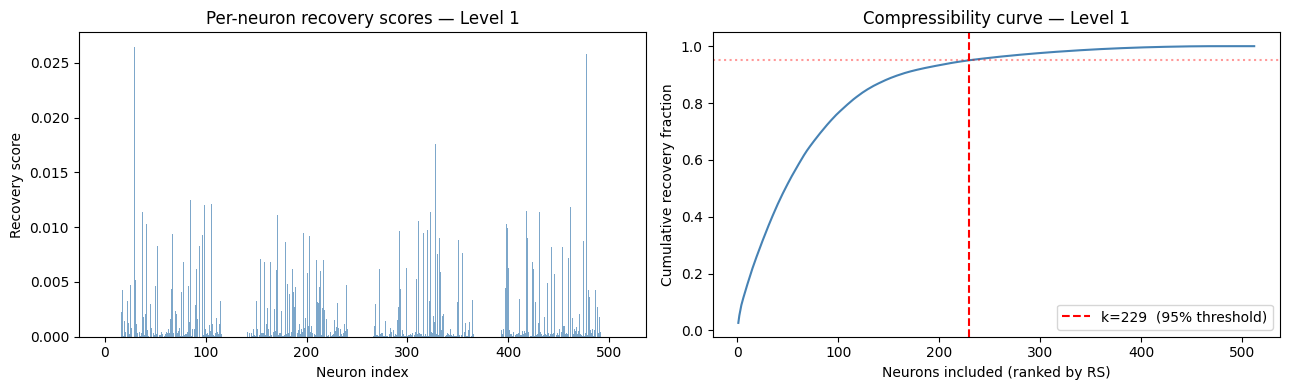

In [30]:
sorted_scores, sorted_idx = scores.sort(descending=True)

# Cumulative recovery curve → Criterion 2 (description length proxy)
pos_scores = sorted_scores.clamp(min=0)
cumulative  = pos_scores.cumsum(0)
total_pos   = cumulative[-1].item()

k_95 = int((cumulative / total_pos >= 0.95).nonzero()[0].item()) + 1
circuit_neurons = sorted_idx[:k_95].tolist()

# Criterion 1: run the k_95-neuron circuit together
def circuit_hook(value, hook):
    value[:, -1, :] = mean_acts.to(value.device)
    for n in circuit_neurons:
        value[:, -1, n] = clean_acts[:, n].to(value.device)
    return value

with torch.no_grad():
    circuit_logits = model.run_with_hooks(
        eval_x, fwd_hooks=[(HOOK, circuit_hook)])[:, -1, :]
circuit_metric  = logit_of_correct(circuit_logits, eval_y)
faithfulness    = recovery_score(circuit_metric, corrupted_metric, clean_metric)


print("Level 1: Neuron/parameter level")
print(f"Criterion 1  Faithfulness RS : {faithfulness:.4f}")
print(f"Criterion 2  Component count : {k_95} / {d_mlp} neurons")
print(f"Compression ratio: {k_95/d_mlp:.3f}")


# Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(range(d_mlp), scores.numpy(), color="steelblue", alpha=0.7)
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_xlabel("Neuron index")
ax1.set_ylabel("Recovery score")
ax1.set_title("Per-neuron recovery scores — Level 1")

ax2.plot(range(1, d_mlp + 1), cumulative.numpy() / total_pos, color="steelblue")
ax2.axvline(k_95, color="red", linestyle="--", label=f"k={k_95}  (95% threshold)")
ax2.axhline(0.95, color="red", linestyle=":", alpha=0.4)
ax2.set_xlabel("Neurons included (ranked by RS)")
ax2.set_ylabel("Cumulative recovery fraction")
ax2.set_title("Compressibility curve — Level 1")
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "level1_recovery_scores.png", dpi=150)
plt.show()

Save results

In [31]:
results = {
    "level": 1,
    "task": "modular_arithmetic_mod113",
    "hook_point": HOOK,
    "d_mlp": d_mlp,
    "n_eval": N_EVAL,
    "clean_metric_mean":     clean_metric.mean().item(),
    "corrupted_metric_mean": corrupted_metric.mean().item(),
    "criterion1_faithfulness": faithfulness,
    "criterion2_component_count": k_95,
    "criterion2_compression_ratio": k_95 / d_mlp,
    "circuit_neurons": circuit_neurons,
    "all_recovery_scores": scores.tolist(),
}

with open(RESULTS_DIR / "level1_results.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {RESULTS_DIR}/level1_results.json")

Results saved to ..\results\level1/level1_results.json


notes for thesis

**Criterion 1: Faithfulness: 0.9501**

229 neurons recover 95% of the clean model's logit gap. That's a strong result — it means the circuit is genuinely doing the task. The 0.05 gap left is likely split between the attention head and noise.

**Criterion 2: Component count: 229 / 512 (ratio 0.447)**

This is the more interesting number philosophically. 45% of all MLP neurons are needed to reach 95% faithfulness: the circuit is not sparse at the neuron level. If the circuit were naturally expressed at the neuron level, you'd expect a much smaller fraction. the neuron level is *faithful* but not *compressible*.

For reference, Nanda et al. 2023 found that the grokking circuit is most naturally described in terms of Fourier components and specific attention heads, which is a Level 2 / Level 3, not a Level 1. 0.447 compression ratio is consistent with that finding.


the key comparison is whether Level 2 (attention heads) achieves a similar faithfulness with a lower component count, and whether Level 3 (SAE features) shifts the trade-off again.